In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

In [ ]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,random_state=23)

In [ ]:
X.shape

(1000, 2)

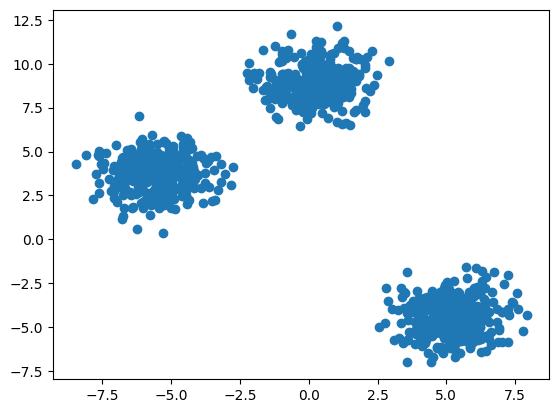

In [ ]:
plt.scatter(X[:,0],X[:,1])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
## Manual Process
## Elbow Method to select the K Value

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1171.9724987764512,
 1056.3209460784553,
 855.863849375211,
 764.3269921861106,
 672.4753297551251,
 582.5173440931044,
 544.6535138907848]

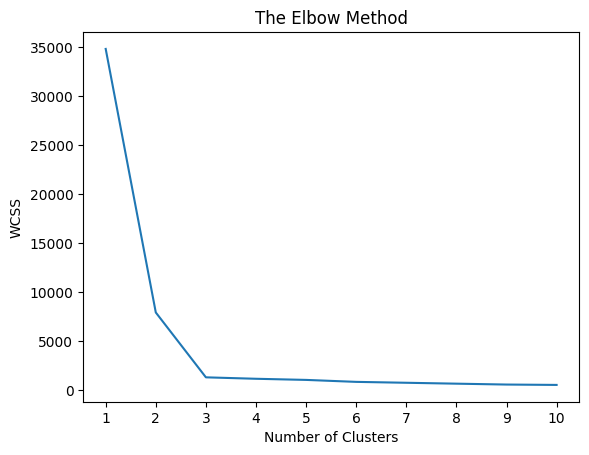

In [ ]:
##Plot Elbow Curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,init="k-means++")
y_labels=kmeans.fit_predict(X_train)

In [ ]:
y_test_labels=kmeans.predict(X_test)

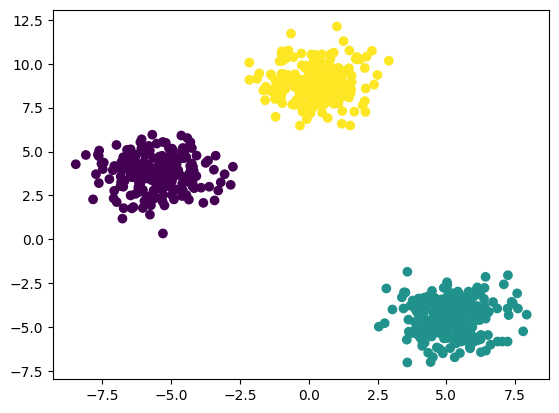

In [ ]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

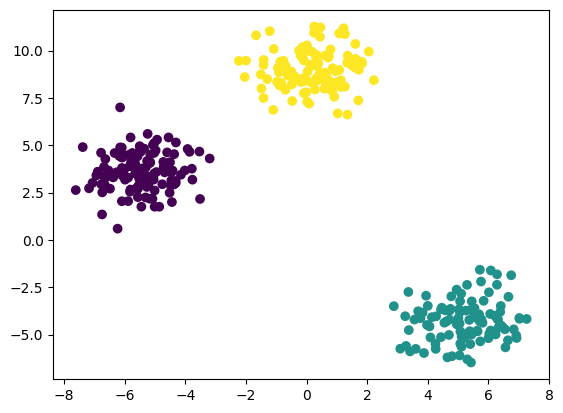

In [ ]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_labels)

In [ ]:
## knee locator
!pip install kneed

In [ ]:
from kneed import KneeLocator

In [ ]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [ ]:
## Performance metrics
## silhoutte score
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [ ]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6505454471731087),
 np.float64(0.4709659373540625),
 np.float64(0.4870250528143744),
 np.float64(0.3418634013487947),
 np.float64(0.31035626546563017),
 np.float64(0.34592723639960404),
 np.float64(0.3419717733326303)]

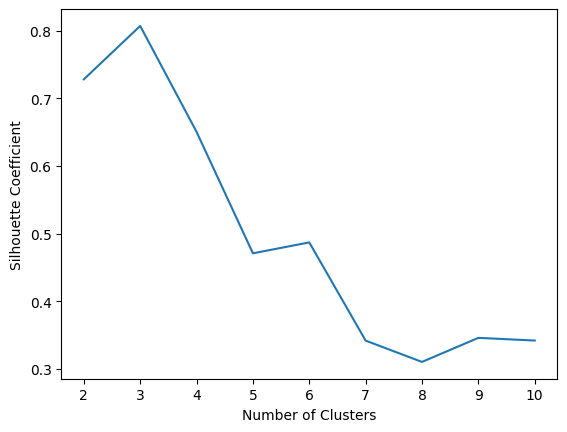

In [ ]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()